The aim of this notebook is to be able to develop an augmented reality (AR) video, using two source videos. The first video shows two books: Computer Vision (A Modern Approach) and Multiple View Geometry (in computer vision). The second video is the trailer of the animated movie: Kung Fu Panda.

**TASK**

The aim of this task is to be able to overlay every frame of the Kung Fu Panda movie over the Computer Vision book in the second movie.

In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# SIFT function performing the SIFT Descriptor
def SIFT(img):
  # Instantiate SIFT object
  sift = cv2.SIFT_create()
  keypoints, descriptors = sift.detectAndCompute(img, None)
  image_detected_blobs = cv2.drawKeypoints(img, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
  return image_detected_blobs, keypoints, descriptors


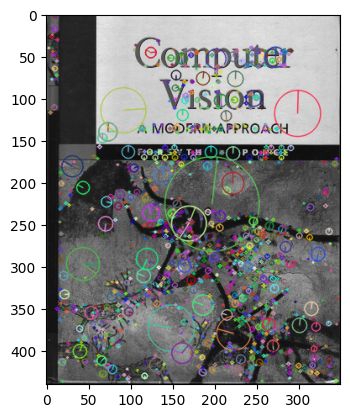

In [29]:
# Reading input image (Book cover)
image = cv2.imread('cv_cover.jpg')
img_grayscale = cv2.imread('cv_cover.jpg', cv2.IMREAD_GRAYSCALE)
# SIFT Outcome plotted
sift_outcome = SIFT(img_grayscale)
image_detected_blobs_A = sift_outcome[0]
keypoints_A = sift_outcome[1]
descriptors_A = sift_outcome[2]
plt.imshow(image_detected_blobs_A)

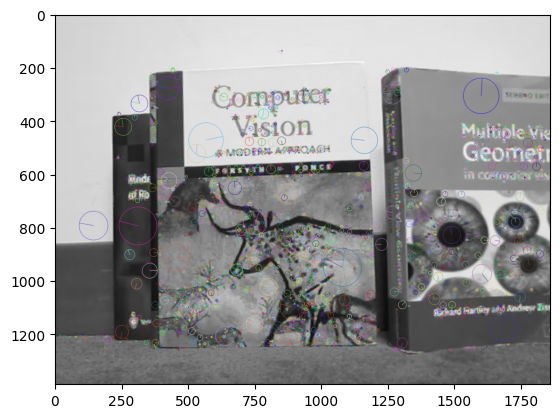

In [30]:
# Reading input image (Book cover -- first frame in the first movie)
image_movie = cv2.imread('cv_cover_movie.jpg')
img_grayscale_movie = cv2.imread('cv_cover_movie.jpg', cv2.IMREAD_GRAYSCALE)
# SIFT Outcome plotted
sift_outcome_movie = SIFT(img_grayscale_movie)
image_detected_blobs_B = sift_outcome_movie[0]
keypoints_B = sift_outcome_movie[1]
descriptors_B = sift_outcome_movie[2]
plt.imshow(image_detected_blobs_B)

In [31]:
# Brute force function. Matcher used to obtain the correspondances between images
def brute_force(image_A, image_keypoints_A ,image_descriptors_A, image_B, image_keypoints_B ,image_descriptors_B):
  brute_force_matcher = cv2.BFMatcher()
  # K Nearest Neighbors, Neighbors = 2
  neighbors = 2
  matches = brute_force_matcher.knnMatch(image_descriptors_A, image_descriptors_B, neighbors)
  matches = sorted(matches, key=lambda x:x[0].distance)
  # Select only good matches according to ratio. According to Lowe's paper, a match with ratio of 0.65 is a good match
  ratio = 0.65
  good_matches = []
  for m, n in matches:
    if m.distance < ratio*n.distance:
      good_matches.append([m])
  number_of_matches = 50
  good_matches = good_matches[:number_of_matches]
  image_with_matches = cv2.drawMatchesKnn(image_A, image_keypoints_A, image_B, image_keypoints_B, good_matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
  return image_with_matches

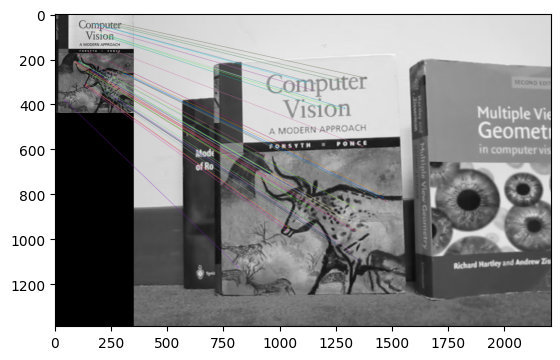

In [32]:
# Brute force matcher outcome
brute_force_outcome = brute_force(img_grayscale, keypoints_A, descriptors_A, img_grayscale_movie, keypoints_B, descriptors_B)
plt.imshow(brute_force_outcome)
